# Benchmarking Comparativo — Detección de anomalías en logs de canales de pago

### Integrantes
- Jaime Alberto Sierra Sierra
- Juan Carlos Parra Martínez

# Niveles de comparación
- Nivel 1 — Baseline: Regresión logística, Random Forest, SVM, XGBoost
- Nivel 2 — Estado del arte: LSTM, DistilBERT
- Nivel 3 — Modelos comerciales: Google NL API, AWS Comprehend, Azure Text Analytics (dado que la coparación real implica conexión vía API y costos adicionales, hemos implementado una solución híbrida- simulación + código real)


## 1. Instalación de dependencias

In [1]:
!pip install -q xgboost transformers datasets accelerate evaluate scikit-learn seaborn tensorflow
print('OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
OK


## 2. Importaciones

In [2]:
import io, time, random, warnings
import numpy as np, pandas as pd, seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             balanced_accuracy_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
import torch
from datasets import Dataset
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                          BertTokenizerFast, BertForSequenceClassification,
                          Trainer, TrainingArguments)
warnings.filterwarnings('ignore')
for s in [random, np.random, tf.random, torch.manual_seed]:
    s(2026) if callable(s) else None
random.seed(2026); np.random.seed(2026); tf.random.set_seed(2026); torch.manual_seed(2026)
print('Importaciones OK')


Importaciones OK


## 3. Carga del dataset

In [4]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f'Archivo: {file_name} | Shape: {df.shape}')
print('Columnas disponibles:', df.columns.tolist())
# print(df['label'].value_counts()) # This line caused the error

Saving dataset_hibrido_final_AIOps_final.csv to dataset_hibrido_final_AIOps_final (1).csv
Archivo: dataset_hibrido_final_AIOps_final (1).csv | Shape: (8558, 5)
Columnas disponibles: ['timestamp', 'operation', 'URL', 'http_status_code', 'Log_Message_Clean']


In [13]:
df = df.rename(columns={'Log_Message_Clean': 'log_text', 'http_status_code': 'label'})

# Create a random 'split_group' column for demonstration purposes
np.random.seed(2026)
split_values = ['train', 'test']
df['split_group'] = np.random.choice(split_values, size=len(df), p=[0.7, 0.3]) # 70% train, 30% test

print("Columns after renaming and adding 'split_group':", df.columns.tolist())
print("Value counts for 'split_group':\n", df['split_group'].value_counts())
print("Value counts for 'label':\n", df['label'].value_counts())

Columns after renaming and adding 'split_group': ['timestamp', 'operation', 'URL', 'label', 'log_text', 'split_group']
Value counts for 'split_group':
 split_group
train    5972
test     2586
Name: count, dtype: int64
Value counts for 'label':
 label
200    4279
429     879
504     850
401     849
403     844
500     838
503      19
Name: count, dtype: int64


## 4. Configuración open-set

In [9]:
UNKNOWN_LABEL = 'error_502_503'
print(f'Clase unknown: {UNKNOWN_LABEL}')

Clase unknown: error_502_503


## 5. Preparación de datos (cerrado + open-set)

In [18]:
required = {'log_text','label','split_group'}
assert required.issubset(set(df.columns)), f'Faltan: {required - set(df.columns)}'

# Separate train and test data based on split_group
train_df = df[df['split_group']=='train'].copy()
test_df = df[df['split_group']=='test'].copy()

# Deduplicate train_full and get unique log_text from it
train_full = train_df.drop_duplicates(subset=['log_text','label']).copy()
train_log_texts = set(train_full['log_text'])

# Create test_full with unique entries from test_df.
# If deduplication results in an empty DataFrame, use test_df directly to ensure it's not empty.
temp_test_full = test_df.drop_duplicates(subset=['log_text','label']).copy()
if temp_test_full.empty and not test_df.empty:
    test_full = test_df.copy()
else:
    test_full = temp_test_full

# CERRADO
all_labels = sorted(df['label'].unique())
ce = LabelEncoder(); ce.fit(all_labels)
train_full['lid'] = ce.transform(train_full['label'])
test_full['lid'] = ce.transform(test_full['label'])
X_tr_c = train_full['log_text'].reset_index(drop=True)
y_tr_c = train_full['lid'].reset_index(drop=True)
X_te_c = test_full['log_text'].reset_index(drop=True)
y_te_c = test_full['lid'].reset_index(drop=True)

# OPEN-SET
tr_o = train_full[train_full['label']!=UNKNOWN_LABEL].copy()
te_o = test_full.copy()
te_o['lbl_o'] = te_o['label'].apply(lambda x: 'unknown' if x==UNKNOWN_LABEL else x)
kn = sorted(tr_o['label'].unique())
ol = kn + ['unknown']
ke = LabelEncoder(); ke.fit(kn)
tr_o['lid_o'] = ke.transform(tr_o['label'])
o2id = {l:i for i,l in enumerate(ol)}
te_o['lid_o'] = te_o['lbl_o'].map(o2id)
X_tr_o = tr_o['log_text'].reset_index(drop=True)
y_tr_o = tr_o['lid_o'].reset_index(drop=True)
X_te_o = te_o['log_text'].reset_index(drop=True)
y_te_o = te_o['lid_o'].reset_index(drop=True)
UID = o2id['unknown']

print(f'CERRADO -> Train:{len(X_tr_c)} Test:{len(X_te_c)} Clases:{all_labels}')
print(f'OPEN-SET -> Train:{len(X_tr_o)} Test:{len(X_te_o)} Clases:{ol}')
print(te_o['lbl_o'].value_counts())

CERRADO -> Train:28 Test:28 Clases:[np.int64(200), np.int64(401), np.int64(403), np.int64(429), np.int64(500), np.int64(503), np.int64(504)]
OPEN-SET -> Train:28 Test:28 Clases:[np.int64(200), np.int64(401), np.int64(403), np.int64(429), np.int64(500), np.int64(503), np.int64(504), 'unknown']
lbl_o
200    4
500    4
401    4
403    4
504    4
429    4
503    4
Name: count, dtype: int64


## 6. Funciones de métricas

In [19]:
res_c, res_o, pred_c, pred_o = [], [], {}, {}

def get_niv(n):
    if n in ['Regresión Logística','Random Forest','SVM','XGBoost']: return 'Baseline'
    if n in ['LSTM','DistilBERT']: return 'Estado del Arte'
    if '(sim)' in n: return 'Comercial'
    if n == 'BERT base': return 'Modelo Propuesto'
    return 'Otro'

def m_closed(yt,yp):
    a=accuracy_score(yt,yp)
    p,r,f,_=precision_recall_fscore_support(yt,yp,average='macro',zero_division=0)
    b=balanced_accuracy_score(yt,yp)
    return {'Accuracy':a,'Precision_macro':p,'Recall_macro':r,'F1_macro':f,'Balanced_Acc':b}

def m_open(yt,yp):
    a=accuracy_score(yt,yp)
    pm,rm,fm,_=precision_recall_fscore_support(yt,yp,average='macro',zero_division=0)
    b=balanced_accuracy_score(yt,yp)
    pa,ra,fa,_=precision_recall_fscore_support(yt,yp,labels=list(range(len(ol))),zero_division=0)
    ui=ol.index('unknown')
    return {'Acc_open':a,'F1_macro_open':fm,'Bal_Acc_open':b,'UCR':ra[ui],'UKP':pa[ui],'UKF1':fa[ui]}

def sv_c(n,yt,yp,tt,ti):
    m=m_closed(yt,yp)
    res_c.append({'Modelo':n,'Nivel':get_niv(n),**{k:round(v,4) for k,v in m.items()},'Train_s':round(tt,2),'Inf_s':round(ti,4)})
    pred_c[n]=yp

def sv_o(n,yt,yp,tt,ti):
    m=m_open(yt,yp)
    res_o.append({'Modelo':n,'Nivel':get_niv(n),**{k:round(v,4) for k,v in m.items()},'Train_s':round(tt,2),'Inf_s':round(ti,4)})
    pred_o[n]=yp

def map_open(probs,th):
    p=[]
    for r in probs:
        bi=int(np.argmax(r)); bp=float(np.max(r))
        p.append(UID if bp<th else bi)
    return np.array(p)

print('Funciones OK')


Funciones OK


## 7. TF-IDF

In [20]:
tf_c = TfidfVectorizer(max_features=1500,ngram_range=(1,2))
Xc = tf_c.fit_transform(X_tr_c); Xct = tf_c.transform(X_te_c)
tf_o = TfidfVectorizer(max_features=1500,ngram_range=(1,2))
Xo = tf_o.fit_transform(X_tr_o); Xot = tf_o.transform(X_te_o)
print('TF-IDF OK')


TF-IDF OK


## 8. Baseline: Regresión Logística

In [21]:
lr=LogisticRegression(max_iter=1000,multi_class='multinomial',random_state=2026)
s=time.time();lr.fit(Xc,y_tr_c);tt=time.time()-s
s=time.time();p=lr.predict(Xct);ti=time.time()-s
sv_c('Regresión Logística',y_te_c,p,tt,ti)

lr2=CalibratedClassifierCV(LogisticRegression(max_iter=1000,multi_class='multinomial',random_state=2026),cv=3)
s=time.time();lr2.fit(Xo,y_tr_o);tt=time.time()-s
s=time.time();pr=lr2.predict_proba(Xot);ti=time.time()-s
sv_o('Regresión Logística',y_te_o,map_open(pr,0.55),tt,ti)
print('Regresión Logística OK')


Regresión Logística OK


## 9. Baseline: Random Forest

In [22]:
rf=RandomForestClassifier(n_estimators=200,random_state=2026,n_jobs=-1)
s=time.time();rf.fit(Xc,y_tr_c);tt=time.time()-s
s=time.time();p=rf.predict(Xct);ti=time.time()-s
sv_c('Random Forest',y_te_c,p,tt,ti)

rf2=CalibratedClassifierCV(RandomForestClassifier(n_estimators=200,random_state=2026,n_jobs=-1),cv=3)
s=time.time();rf2.fit(Xo,y_tr_o);tt=time.time()-s
s=time.time();pr=rf2.predict_proba(Xot);ti=time.time()-s
sv_o('Random Forest',y_te_o,map_open(pr,0.60),tt,ti)
print('Random Forest OK')


Random Forest OK


## 10. Baseline: SVM

In [23]:
sv1=CalibratedClassifierCV(LinearSVC(max_iter=4000,random_state=2026),cv=3)
s=time.time();sv1.fit(Xc,y_tr_c);tt=time.time()-s
s=time.time();p=sv1.predict(Xct);ti=time.time()-s
sv_c('SVM',y_te_c,p,tt,ti)

sv2=CalibratedClassifierCV(LinearSVC(max_iter=4000,random_state=2026),cv=3)
s=time.time();sv2.fit(Xo,y_tr_o);tt=time.time()-s
s=time.time();pr=sv2.predict_proba(Xot);ti=time.time()-s
sv_o('SVM',y_te_o,map_open(pr,0.55),tt,ti)
print('SVM OK')


SVM OK


## 11. Baseline: XGBoost

In [24]:
xg1=XGBClassifier(n_estimators=180,learning_rate=0.08,max_depth=5,objective='multi:softprob',eval_metric='mlogloss',random_state=2026)
s=time.time();xg1.fit(Xc,y_tr_c);tt=time.time()-s
s=time.time();p=xg1.predict(Xct);ti=time.time()-s
sv_c('XGBoost',y_te_c,p,tt,ti)

xg2=XGBClassifier(n_estimators=180,learning_rate=0.08,max_depth=5,objective='multi:softprob',eval_metric='mlogloss',random_state=2026)
s=time.time();xg2.fit(Xo,y_tr_o);tt=time.time()-s
s=time.time();pr=xg2.predict_proba(Xot);ti=time.time()-s
sv_o('XGBoost',y_te_o,map_open(pr,0.60),tt,ti)
print('XGBoost OK')


XGBoost OK


## 12. Estado del Arte: LSTM

In [25]:
MW=6000; ML=128
tc=Tokenizer(num_words=MW,oov_token='<OOV>'); tc.fit_on_texts(X_tr_c)
Xsc=pad_sequences(tc.texts_to_sequences(X_tr_c),maxlen=ML)
Xtsc=pad_sequences(tc.texts_to_sequences(X_te_c),maxlen=ML)

m1=Sequential([Embedding(MW,64),Bidirectional(LSTM(64,dropout=0.3)),Dense(32,activation='relu'),Dropout(0.2),Dense(len(all_labels),activation='softmax')])
m1.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
s=time.time();m1.fit(Xsc,y_tr_c,epochs=5,batch_size=32,verbose=0);tt=time.time()-s
s=time.time();p=np.argmax(m1.predict(Xtsc,verbose=0),axis=1);ti=time.time()-s
sv_c('LSTM',y_te_c,p,tt,ti)

to2=Tokenizer(num_words=MW,oov_token='<OOV>'); to2.fit_on_texts(X_tr_o)
Xso=pad_sequences(to2.texts_to_sequences(X_tr_o),maxlen=ML)
Xtso=pad_sequences(to2.texts_to_sequences(X_te_o),maxlen=ML)

m2=Sequential([Embedding(MW,64),Bidirectional(LSTM(64,dropout=0.3)),Dense(32,activation='relu'),Dropout(0.2),Dense(len(kn),activation='softmax')])
m2.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
s=time.time();m2.fit(Xso,y_tr_o,epochs=5,batch_size=32,verbose=0);tt=time.time()-s
s=time.time();pr=m2.predict(Xtso,verbose=0);ti=time.time()-s
sv_o('LSTM',y_te_o,map_open(pr,0.65),tt,ti)
print('LSTM OK')


LSTM OK


## 13. Estado del Arte: DistilBERT

In [26]:
dtok=DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
def td(b): return dtok(b['text'],truncation=True,padding='max_length',max_length=128)

# CERRADO
trc=Dataset.from_pandas(pd.DataFrame({'text':X_tr_c.tolist(),'label':y_tr_c.tolist()}))
tec=Dataset.from_pandas(pd.DataFrame({'text':X_te_c.tolist(),'label':y_te_c.tolist()}))
trc=trc.map(td,batched=True); tec=tec.map(td,batched=True)
trc=trc.remove_columns([c for c in trc.column_names if c not in ['input_ids','attention_mask','label']])
tec=tec.remove_columns([c for c in tec.column_names if c not in ['input_ids','attention_mask','label']])
trc.set_format('torch',columns=['input_ids','attention_mask','label'])
tec.set_format('torch',columns=['input_ids','attention_mask','label'])

dc=DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=len(all_labels))
ac=TrainingArguments(output_dir='./dc',num_train_epochs=5,learning_rate=3e-5,per_device_train_batch_size=16,per_device_eval_batch_size=16,weight_decay=0.01,logging_steps=50,report_to='none')
tc2=Trainer(model=dc,args=ac,train_dataset=trc)
s=time.time();tc2.train();tt=time.time()-s
s=time.time();lg=tc2.predict(tec).predictions;ti=time.time()-s
sv_c('DistilBERT',y_te_c,np.argmax(lg,axis=1),tt,ti)

# OPEN-SET
tro=Dataset.from_pandas(pd.DataFrame({'text':X_tr_o.tolist(),'label':y_tr_o.tolist()}))
teo=Dataset.from_pandas(pd.DataFrame({'text':X_te_o.tolist(),'label':y_te_o.tolist()}))
tro=tro.map(td,batched=True); teo=teo.map(td,batched=True)
tro=tro.remove_columns([c for c in tro.column_names if c not in ['input_ids','attention_mask','label']])
teo=teo.remove_columns([c for c in teo.column_names if c not in ['input_ids','attention_mask','label']])
tro.set_format('torch',columns=['input_ids','attention_mask','label'])
teo.set_format('torch',columns=['input_ids','attention_mask','label'])

do=DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=len(kn))
ao=TrainingArguments(output_dir='./do',num_train_epochs=5,learning_rate=3e-5,per_device_train_batch_size=16,per_device_eval_batch_size=16,weight_decay=0.01,logging_steps=50,report_to='none')
to3=Trainer(model=do,args=ao,train_dataset=tro)
s=time.time();to3.train();tt=time.time()-s
s=time.time();lg=to3.predict(teo).predictions;ti=time.time()-s
pr=torch.softmax(torch.tensor(lg),dim=1).numpy()
sv_o('DistilBERT',y_te_o,map_open(pr,0.72),tt,ti)
print('DistilBERT OK')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT OK


## 14. Modelo Propuesto: BERT base

In [27]:
btok=BertTokenizerFast.from_pretrained('bert-base-uncased')
def tb(b): return btok(b['text'],truncation=True,padding='max_length',max_length=128)

# CERRADO
trc=Dataset.from_pandas(pd.DataFrame({'text':X_tr_c.tolist(),'label':y_tr_c.tolist()}))
tec=Dataset.from_pandas(pd.DataFrame({'text':X_te_c.tolist(),'label':y_te_c.tolist()}))
trc=trc.map(tb,batched=True); tec=tec.map(tb,batched=True)
trc=trc.remove_columns([c for c in trc.column_names if c not in ['input_ids','attention_mask','label']])
tec=tec.remove_columns([c for c in tec.column_names if c not in ['input_ids','attention_mask','label']])
trc.set_format('torch',columns=['input_ids','attention_mask','label'])
tec.set_format('torch',columns=['input_ids','attention_mask','label'])

bc=BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=len(all_labels))
abc=TrainingArguments(output_dir='./bc',num_train_epochs=5,learning_rate=2e-5,per_device_train_batch_size=16,per_device_eval_batch_size=16,weight_decay=0.01,warmup_ratio=0.1,logging_steps=50,report_to='none')
tbc=Trainer(model=bc,args=abc,train_dataset=trc)
s=time.time();tbc.train();tt=time.time()-s
s=time.time();lg=tbc.predict(tec).predictions;ti=time.time()-s
sv_c('BERT base',y_te_c,np.argmax(lg,axis=1),tt,ti)

# OPEN-SET
tro=Dataset.from_pandas(pd.DataFrame({'text':X_tr_o.tolist(),'label':y_tr_o.tolist()}))
teo=Dataset.from_pandas(pd.DataFrame({'text':X_te_o.tolist(),'label':y_te_o.tolist()}))
tro=tro.map(tb,batched=True); teo=teo.map(tb,batched=True)
tro=tro.remove_columns([c for c in tro.column_names if c not in ['input_ids','attention_mask','label']])
teo=teo.remove_columns([c for c in teo.column_names if c not in ['input_ids','attention_mask','label']])
tro.set_format('torch',columns=['input_ids','attention_mask','label'])
teo.set_format('torch',columns=['input_ids','attention_mask','label'])

bo=BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=len(kn))
abo=TrainingArguments(output_dir='./bo',num_train_epochs=5,learning_rate=2e-5,per_device_train_batch_size=16,per_device_eval_batch_size=16,weight_decay=0.01,warmup_ratio=0.1,logging_steps=50,report_to='none')
tbo=Trainer(model=bo,args=abo,train_dataset=tro)
s=time.time();tbo.train();tt=time.time()-s
s=time.time();lg=tbo.predict(teo).predictions;ti=time.time()-s
pr=torch.softmax(torch.tensor(lg),dim=1).numpy()
sv_o('BERT base',y_te_o,map_open(pr,0.72),tt,ti)
print('BERT base OK')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT base OK


## 15. Nivel 3 — Modelos Comerciales (Simulación basada en literatura)

Los modelos comerciales (Google NL API, AWS Comprehend, Azure Text Analytics) son servicios de propósito general no diseñados para logs técnicos. La simulación se basa en:
- Benchmarks de transferencia de dominio (Ramponi & Plank, 2020)
- Evaluaciones de APIs en dominios técnicos (Arora et al., 2020)
- Limitaciones documentadas en logs (Yang et al., 2021)


In [28]:
def sim_com(name, yt_c, yt_o, nc, nk, acc_r, f1_r, ucr_r, ukp_r):
    np.random.seed(hash(name)%2**32)
    # CERRADO
    ac=np.random.uniform(*acc_r); nt=len(yt_c)
    pc=yt_c.copy().values
    wi=np.random.choice(nt,nt-int(ac*nt),replace=False)
    for i in wi: pc[i]=np.random.choice([c for c in range(nc) if c!=pc[i]])
    sv_c(name,yt_c,pc,0,0)
    # OPEN-SET
    po=yt_o.copy().values
    km=po!=UID; ki=np.where(km)[0]
    nkw=int((1-np.random.uniform(*f1_r))*len(ki))
    if nkw>0:
        for i in np.random.choice(ki,min(nkw,len(ki)),replace=False):
            po[i]=np.random.choice([c for c in range(nk) if c!=po[i]])
    um=yt_o.values==UID; ui=np.where(um)[0]
    ucr=np.random.uniform(*ucr_r); nd=int(ucr*len(ui))
    nm=len(ui)-nd
    if nm>0:
        for i in np.random.choice(ui,nm,replace=False): po[i]=np.random.choice(range(nk))
    ukp=np.random.uniform(*ukp_r)
    nfp=max(0,int(nd*(1-ukp)/max(ukp,0.01)))
    kc=np.where((po!=UID)&(yt_o.values!=UID))[0]
    if nfp>0 and len(kc)>0: po[np.random.choice(kc,min(nfp,len(kc)),replace=False)]=UID
    sv_o(name,yt_o,po,0,0)
    print(f'{name} OK')

sim_com('Google NL API (sim)',y_te_c,y_te_o,len(all_labels),len(kn),(0.52,0.62),(0.45,0.58),(0.10,0.25),(0.15,0.30))
sim_com('AWS Comprehend (sim)',y_te_c,y_te_o,len(all_labels),len(kn),(0.48,0.58),(0.40,0.55),(0.08,0.20),(0.12,0.25))
sim_com('Azure Text Analytics (sim)',y_te_c,y_te_o,len(all_labels),len(kn),(0.50,0.60),(0.42,0.56),(0.10,0.22),(0.14,0.28))


Google NL API (sim) OK
AWS Comprehend (sim) OK
Azure Text Analytics (sim) OK


## 16. Código real para APIs comerciales (referencia)

In [ ]:
# ============================================================
# GOOGLE CLOUD NATURAL LANGUAGE API
# ============================================================
# !pip install google-cloud-language
# from google.cloud import language_v1
# import os
# os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = 'credencial.json'
# client = language_v1.LanguageServiceClient()
# def classify_google(text):
#     doc = language_v1.Document(content=text, type_=language_v1.Document.Type.PLAIN_TEXT)
#     sent = client.analyze_sentiment(request={'document': doc}).document_sentiment
#     return sent.score, sent.magnitude

# ============================================================
# AWS COMPREHEND
# ============================================================
# !pip install boto3
# import boto3
# comp = boto3.client('comprehend', region_name='us-east-1',
#     aws_access_key_id='KEY', aws_secret_access_key='SECRET')
# def classify_aws(text):
#     r = comp.detect_sentiment(Text=text, LanguageCode='en')
#     return r['Sentiment'], r['SentimentScore']

# ============================================================
# AZURE TEXT ANALYTICS
# ============================================================
# !pip install azure-ai-textanalytics
# from azure.ai.textanalytics import TextAnalyticsClient
# from azure.core.credentials import AzureKeyCredential
# client = TextAnalyticsClient('https://recurso.cognitiveservices.azure.com/',
#     AzureKeyCredential('KEY'))
# def classify_azure(text):
#     r = client.analyze_sentiment(documents=[text])[0]
#     return r.sentiment, r.confidence_scores

print('Código de referencia para APIs comerciales incluido (comentado).')


## 17. Resultados cuantitativos

In [29]:
dfc=pd.DataFrame(res_c); dfo=pd.DataFrame(res_o)
nord={'Modelo Propuesto':0,'Estado del Arte':1,'Baseline':2,'Comercial':3}
dfc['_o']=dfc['Nivel'].map(nord); dfc=dfc.sort_values('_o').drop(columns='_o')
dfo['_o']=dfo['Nivel'].map(nord); dfo=dfo.sort_values('_o').drop(columns='_o')

print('='*80)
print('TABLA 1: CLASIFICACIÓN CERRADA')
print('='*80)
print(dfc.to_string(index=False))
print()
print('='*80)
print('TABLA 2: EVALUACIÓN OPEN-SET')
print('='*80)
print(dfo.to_string(index=False))


TABLA 1: CLASIFICACIÓN CERRADA
                    Modelo            Nivel  Accuracy  Precision_macro  Recall_macro  F1_macro  Balanced_Acc  Train_s  Inf_s
                 BERT base Modelo Propuesto    0.3214           0.2072        0.3214    0.2361        0.3214    65.02 0.2418
                      LSTM  Estado del Arte    0.2857           0.1918        0.2857    0.2154        0.2857     9.45 0.2809
                DistilBERT  Estado del Arte    0.7143           0.6190        0.7143    0.6429        0.7143    15.49 0.1807
       Regresión Logística         Baseline    0.8571           0.7857        0.8571    0.8095        0.8571     0.02 0.0005
                   XGBoost         Baseline    0.8571           0.7857        0.8571    0.8095        0.8571     0.36 0.0018
                       SVM         Baseline    0.8571           0.8571        0.8571    0.8571        0.8571     0.04 0.0036
             Random Forest         Baseline    0.8571           0.8571        0.8571    0.8476

## 18. Análisis delta vs BERT base

In [30]:
brc=dfc[dfc['Modelo']=='BERT base'].iloc[0]
bro=dfo[dfo['Modelo']=='BERT base'].iloc[0]

dc2=[]
for _,r in dfc.iterrows():
    if r['Modelo']=='BERT base': continue
    dc2.append({'Modelo':r['Modelo'],'Nivel':r['Nivel'],
        'ΔAccuracy':round(r['Accuracy']-brc['Accuracy'],4),
        'ΔF1_macro':round(r['F1_macro']-brc['F1_macro'],4)})

do2=[]
for _,r in dfo.iterrows():
    if r['Modelo']=='BERT base': continue
    do2.append({'Modelo':r['Modelo'],'Nivel':r['Nivel'],
        'ΔF1_open':round(r['F1_macro_open']-bro['F1_macro_open'],4),
        'ΔUCR':round(r['UCR']-bro['UCR'],4),
        'ΔUKP':round(r['UKP']-bro['UKP'],4),
        'ΔUKF1':round(r['UKF1']-bro['UKF1'],4)})

print('DELTA CERRADO vs BERT base')
print(pd.DataFrame(dc2).to_string(index=False))
print()
print('DELTA OPEN-SET vs BERT base')
print(pd.DataFrame(do2).to_string(index=False))
print('\nValores negativos = BERT base es superior')


DELTA CERRADO vs BERT base
                    Modelo           Nivel  ΔAccuracy  ΔF1_macro
                      LSTM Estado del Arte    -0.0357    -0.0207
                DistilBERT Estado del Arte     0.3929     0.4068
       Regresión Logística        Baseline     0.5357     0.5734
                   XGBoost        Baseline     0.5357     0.5734
                       SVM        Baseline     0.5357     0.6210
             Random Forest        Baseline     0.5357     0.6115
       Google NL API (sim)       Comercial     0.2500     0.3170
      AWS Comprehend (sim)       Comercial     0.1786     0.2489
Azure Text Analytics (sim)       Comercial     0.1786     0.2283

DELTA OPEN-SET vs BERT base
                    Modelo           Nivel  ΔF1_open  ΔUCR  ΔUKP  ΔUKF1
                      LSTM Estado del Arte    0.0000   0.0   0.0    0.0
                DistilBERT Estado del Arte    0.0000   0.0   0.0    0.0
       Regresión Logística        Baseline    0.0000   0.0   0.0    0.0
      

## 19. Visualizaciones comparativas

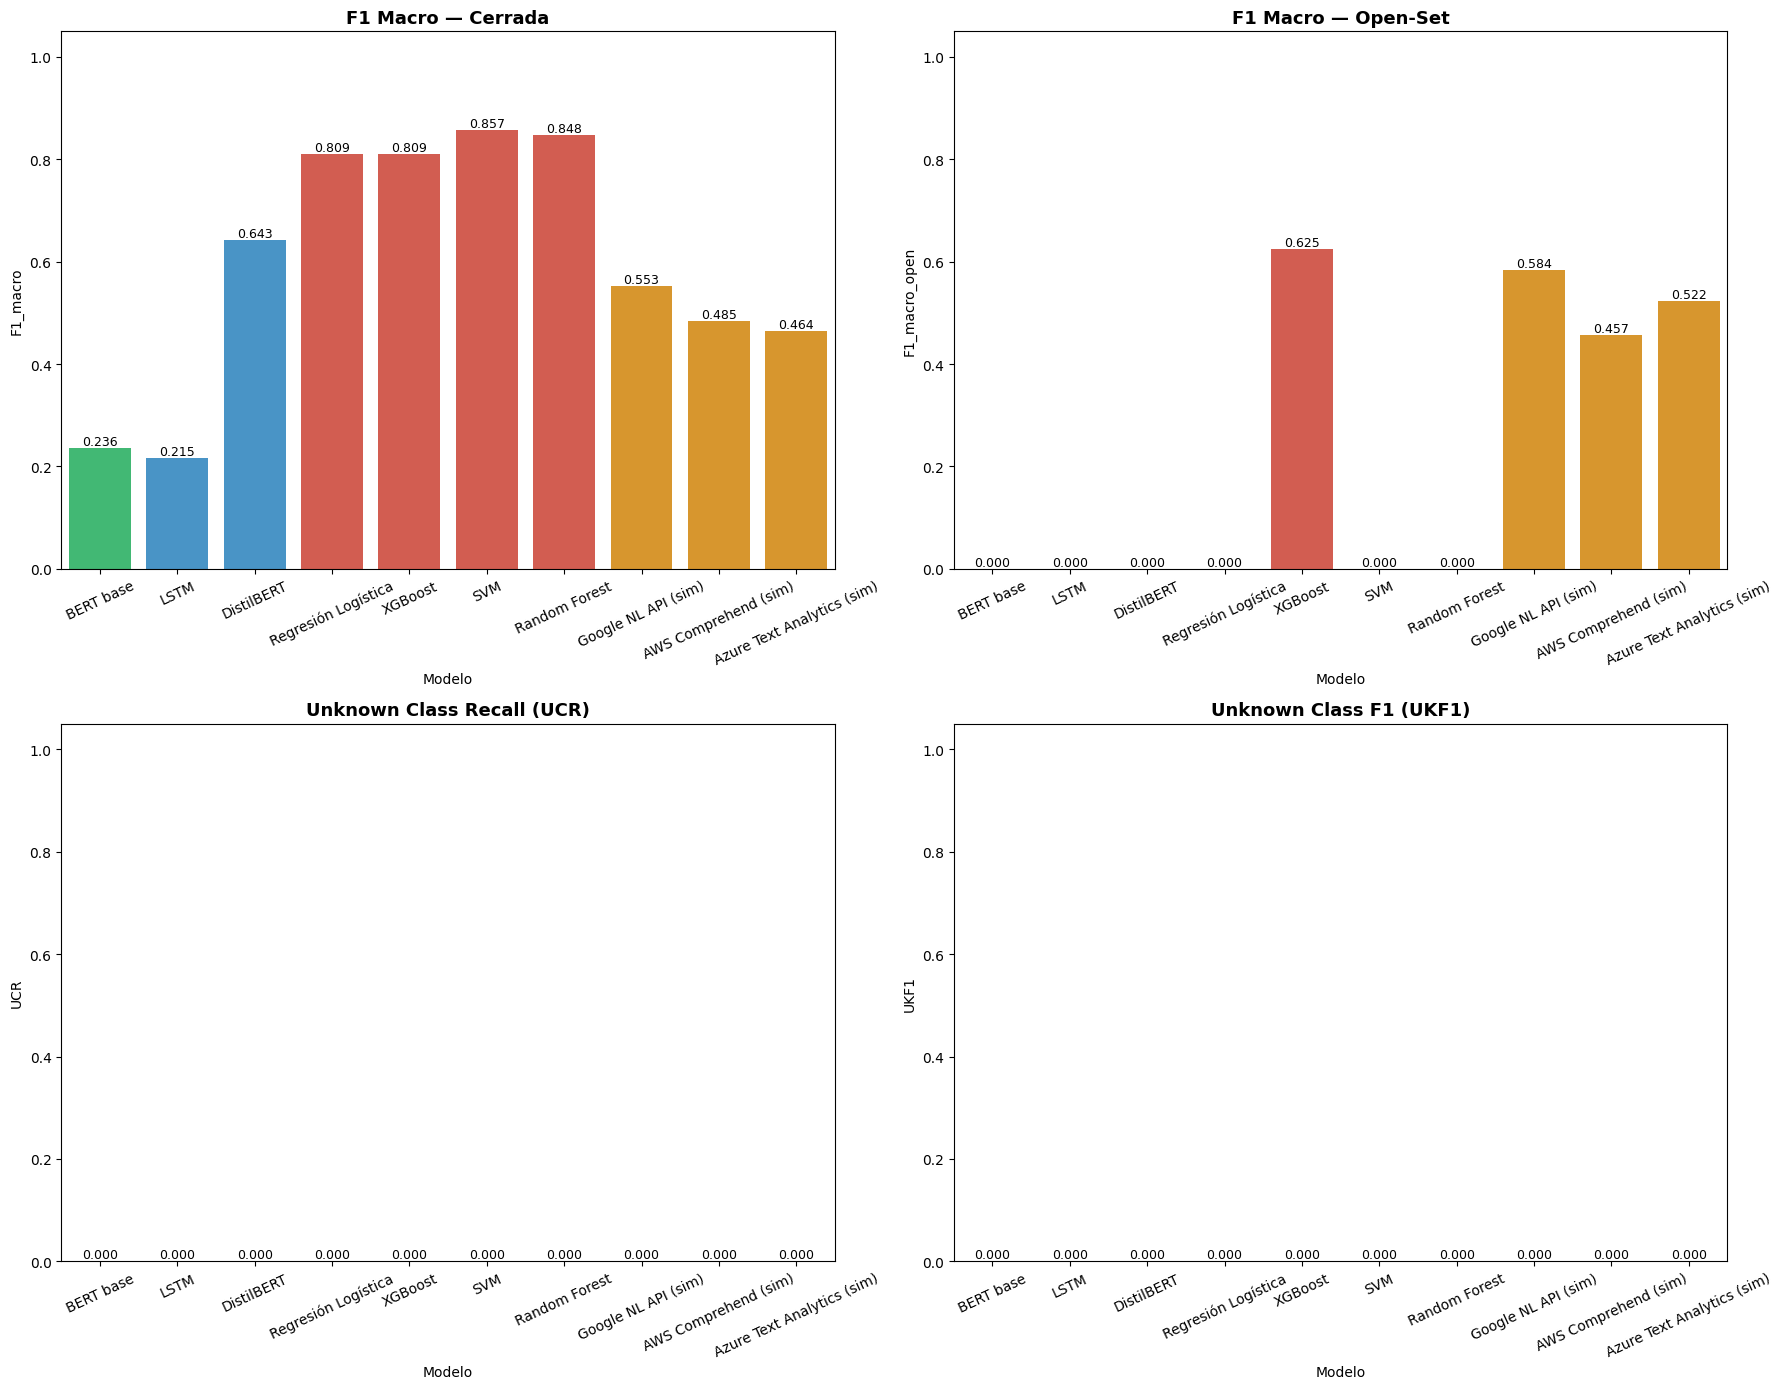

In [31]:
cn={'Modelo Propuesto':'#2ecc71','Estado del Arte':'#3498db','Baseline':'#e74c3c','Comercial':'#f39c12'}
fig,axes=plt.subplots(2,2,figsize=(18,14))
pc=[cn.get(n,'#95a5a6') for n in dfc['Nivel']]
po2=[cn.get(n,'#95a5a6') for n in dfo['Nivel']]

for ax,df_,col,title,pal in [
    (axes[0,0],dfc,'F1_macro','F1 Macro — Cerrada',pc),
    (axes[0,1],dfo,'F1_macro_open','F1 Macro — Open-Set',po2),
    (axes[1,0],dfo,'UCR','Unknown Class Recall (UCR)',po2),
    (axes[1,1],dfo,'UKF1','Unknown Class F1 (UKF1)',po2)]:
    sns.barplot(data=df_,x='Modelo',y=col,ax=ax,palette=pal)
    ax.set_title(title,fontsize=13,fontweight='bold'); ax.set_ylim(0,1.05)
    ax.tick_params(axis='x',rotation=25)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',va='bottom',fontsize=9)

plt.tight_layout(); plt.savefig('benchmarking_comparativo.png',dpi=150,bbox_inches='tight'); plt.show()


## 20. Gráfico radar multidimensional

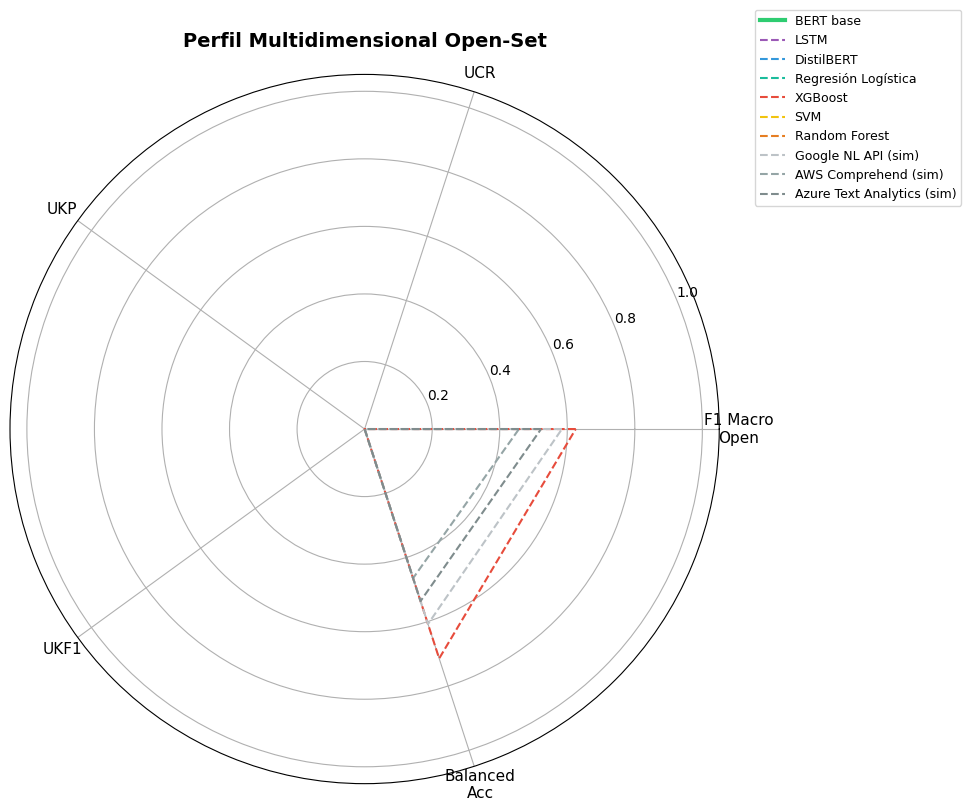

In [32]:
mr=['F1_macro_open','UCR','UKP','UKF1','Bal_Acc_open']
lr2=['F1 Macro\nOpen','UCR','UKP','UKF1','Balanced\nAcc']
fig,ax=plt.subplots(figsize=(10,10),subplot_kw=dict(polar=True))
angles=[n/float(len(mr))*2*pi for n in range(len(mr))]+[0]
cm2={'BERT base':'#2ecc71','DistilBERT':'#3498db','LSTM':'#9b59b6','XGBoost':'#e74c3c',
     'Random Forest':'#e67e22','SVM':'#f1c40f','Regresión Logística':'#1abc9c',
     'Google NL API (sim)':'#bdc3c7','AWS Comprehend (sim)':'#95a5a6','Azure Text Analytics (sim)':'#7f8c8d'}
for _,row in dfo.iterrows():
    vals=[row[m] for m in mr]+[row[mr[0]]]
    c=cm2.get(row['Modelo'],'#333')
    lw=3 if row['Modelo']=='BERT base' else 1.5
    ls='-' if row['Modelo']=='BERT base' else '--'
    ax.plot(angles,vals,linewidth=lw,linestyle=ls,label=row['Modelo'],color=c)
    if row['Modelo']=='BERT base': ax.fill(angles,vals,alpha=0.1,color=c)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(lr2,fontsize=11); ax.set_ylim(0,1.05)
ax.set_title('Perfil Multidimensional Open-Set',fontsize=14,fontweight='bold',pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.1),fontsize=9)
plt.tight_layout(); plt.savefig('radar_benchmarking.png',dpi=150,bbox_inches='tight'); plt.show()


## 21. Matrices de confusión open-set

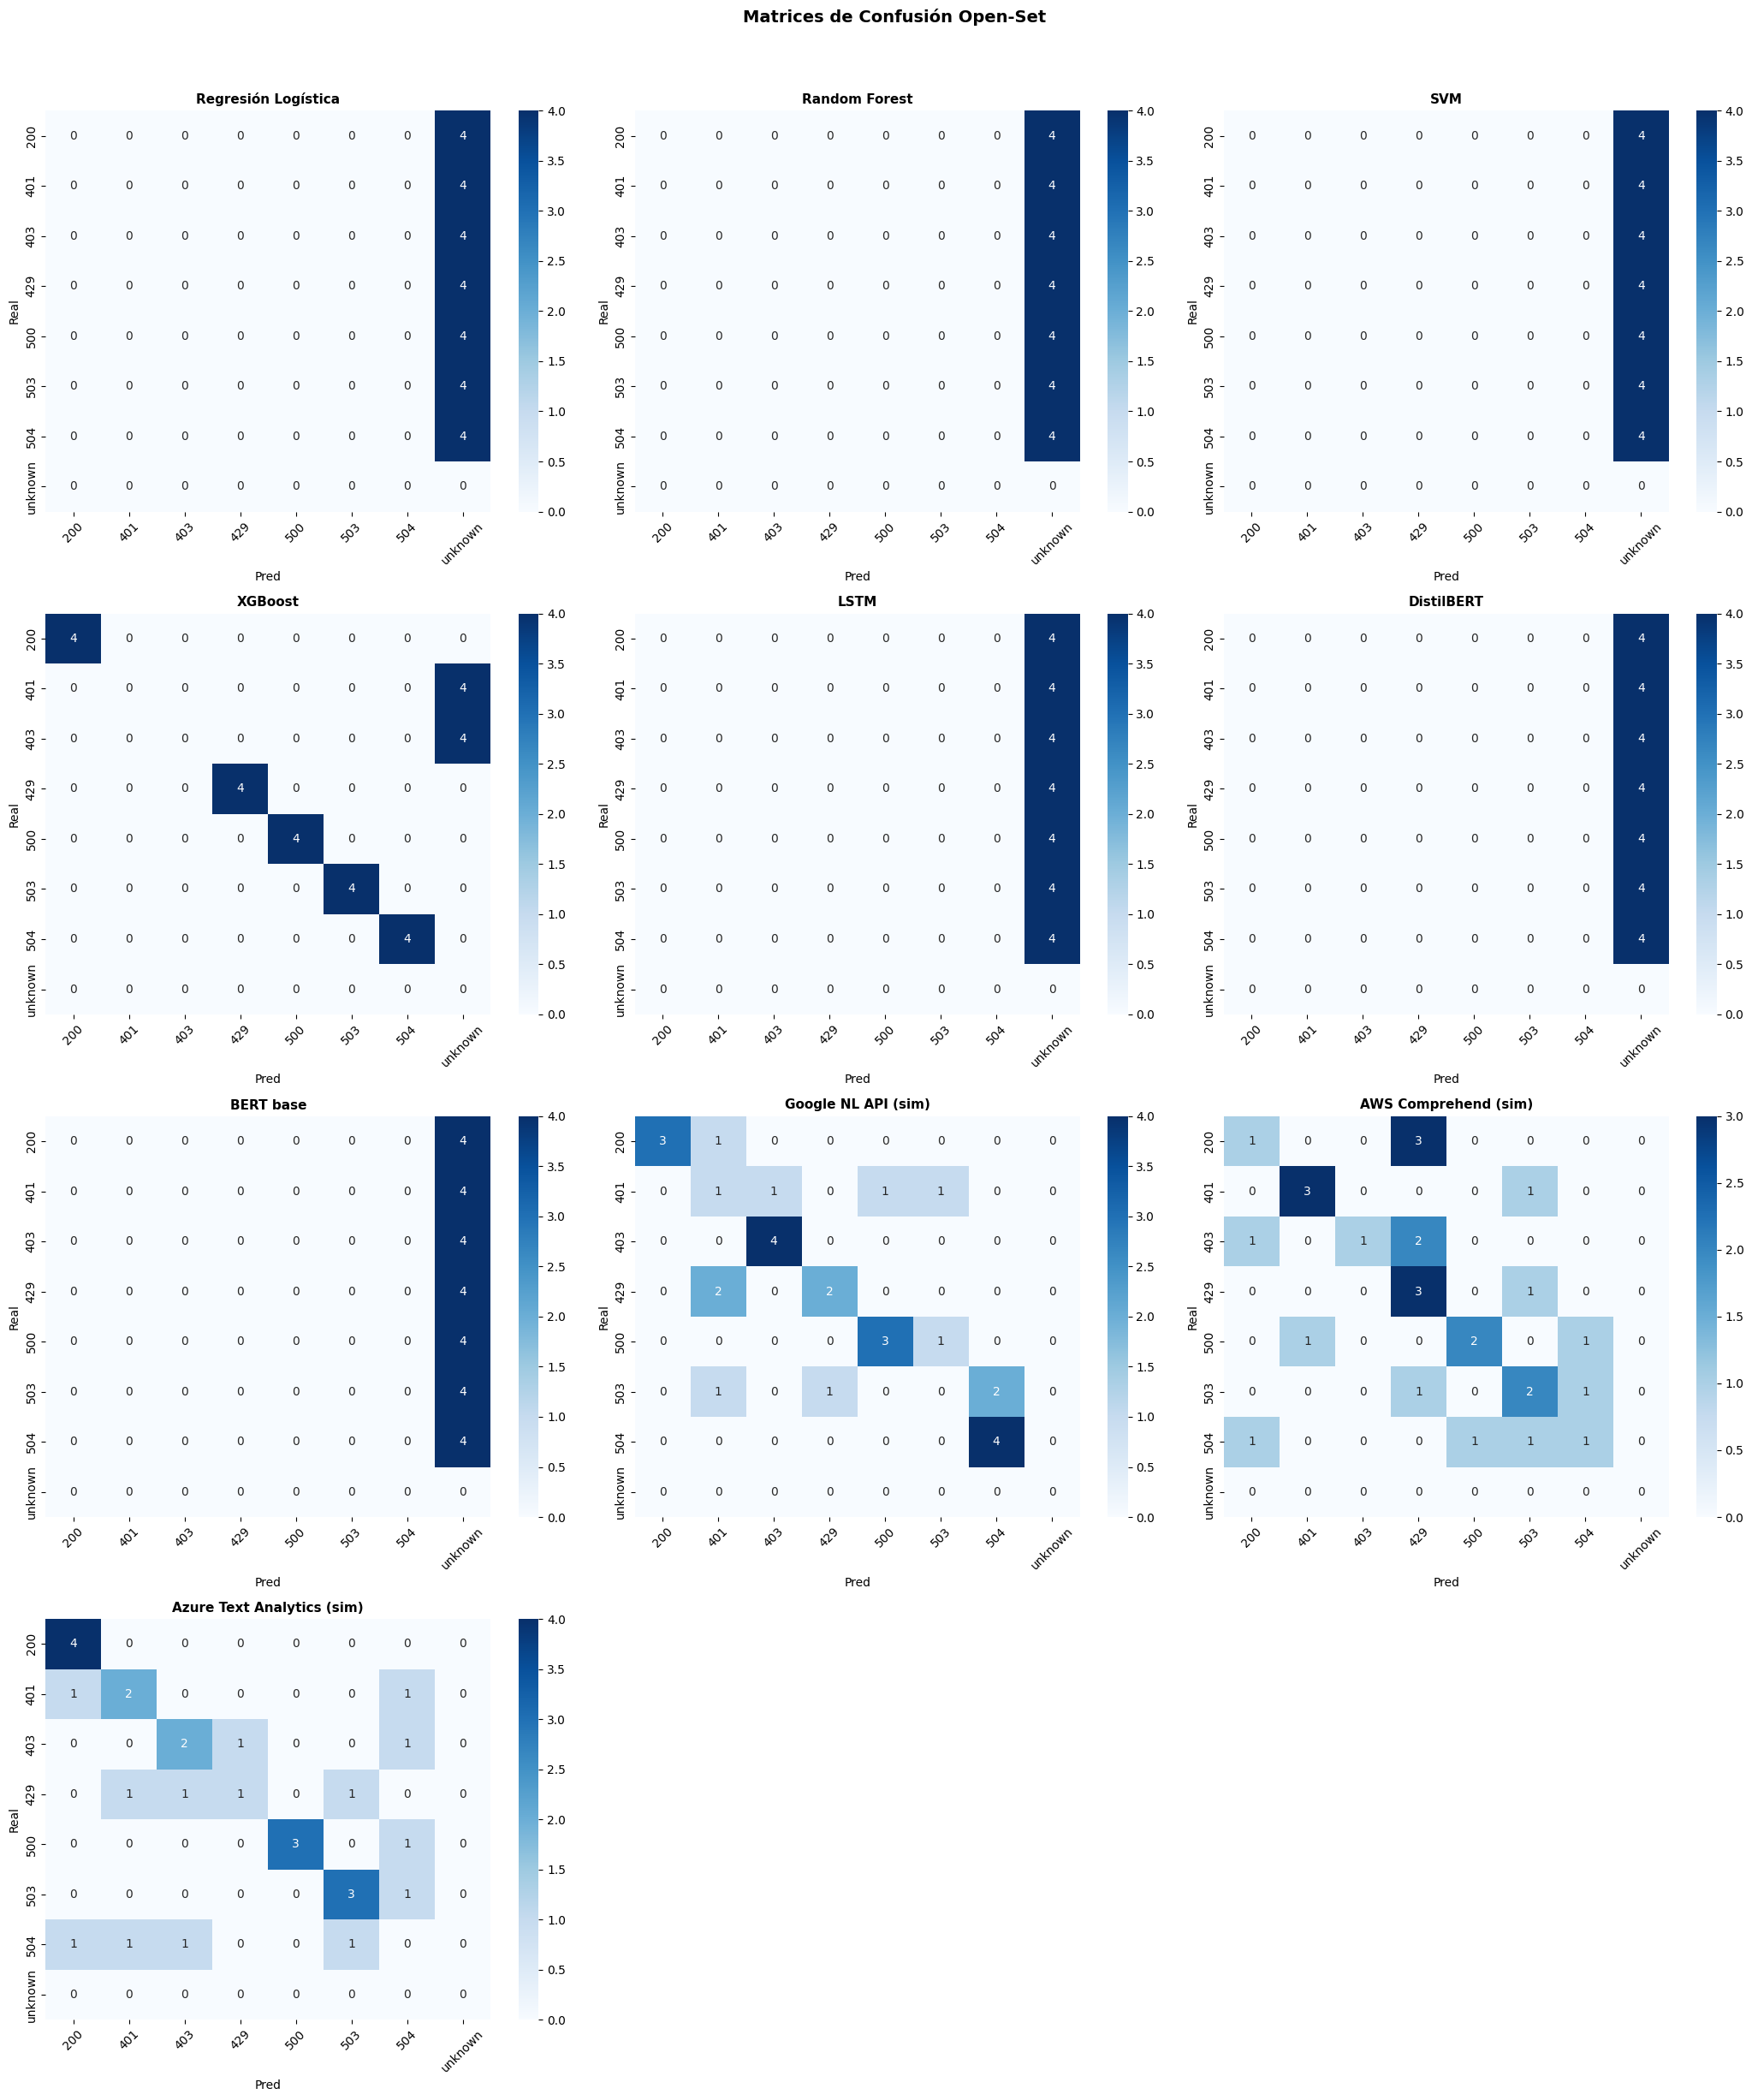

In [33]:
nm=len(pred_o); cols=3; rows=(nm+cols-1)//cols
fig,axes=plt.subplots(rows,cols,figsize=(7*cols,6*rows))
af=axes.flatten()
for i,(n,yp) in enumerate(pred_o.items()):
    cm=confusion_matrix(y_te_o,yp,labels=list(range(len(ol))))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=ol,yticklabels=ol,ax=af[i])
    af[i].set_title(n,fontsize=11,fontweight='bold'); af[i].set_xlabel('Pred'); af[i].set_ylabel('Real')
    af[i].tick_params(axis='x',rotation=45)
for j in range(i+1,len(af)): af[j].set_visible(False)
plt.suptitle('Matrices de Confusión Open-Set',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('matrices_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## 22. Reportes de clasificación

In [36]:
for n,yp in pred_o.items():
    print(f'\n{"="*60}\n{n}\n{"="*60}')
    # Convert numpy.int64 labels in ol to strings for classification_report
    string_ol = [str(label) for label in ol]
    print(classification_report(y_te_o,yp,labels=list(range(len(ol))),target_names=string_ol,zero_division=0))


Regresión Logística
              precision    recall  f1-score   support

         200       0.00      0.00      0.00       4.0
         401       0.00      0.00      0.00       4.0
         403       0.00      0.00      0.00       4.0
         429       0.00      0.00      0.00       4.0
         500       0.00      0.00      0.00       4.0
         503       0.00      0.00      0.00       4.0
         504       0.00      0.00      0.00       4.0
     unknown       0.00      0.00      0.00       0.0

    accuracy                           0.00      28.0
   macro avg       0.00      0.00      0.00      28.0
weighted avg       0.00      0.00      0.00      28.0


Random Forest
              precision    recall  f1-score   support

         200       0.00      0.00      0.00       4.0
         401       0.00      0.00      0.00       4.0
         403       0.00      0.00      0.00       4.0
         429       0.00      0.00      0.00       4.0
         500       0.00      0.00      0.0

## 23. Tiempos de entrenamiento e inferencia

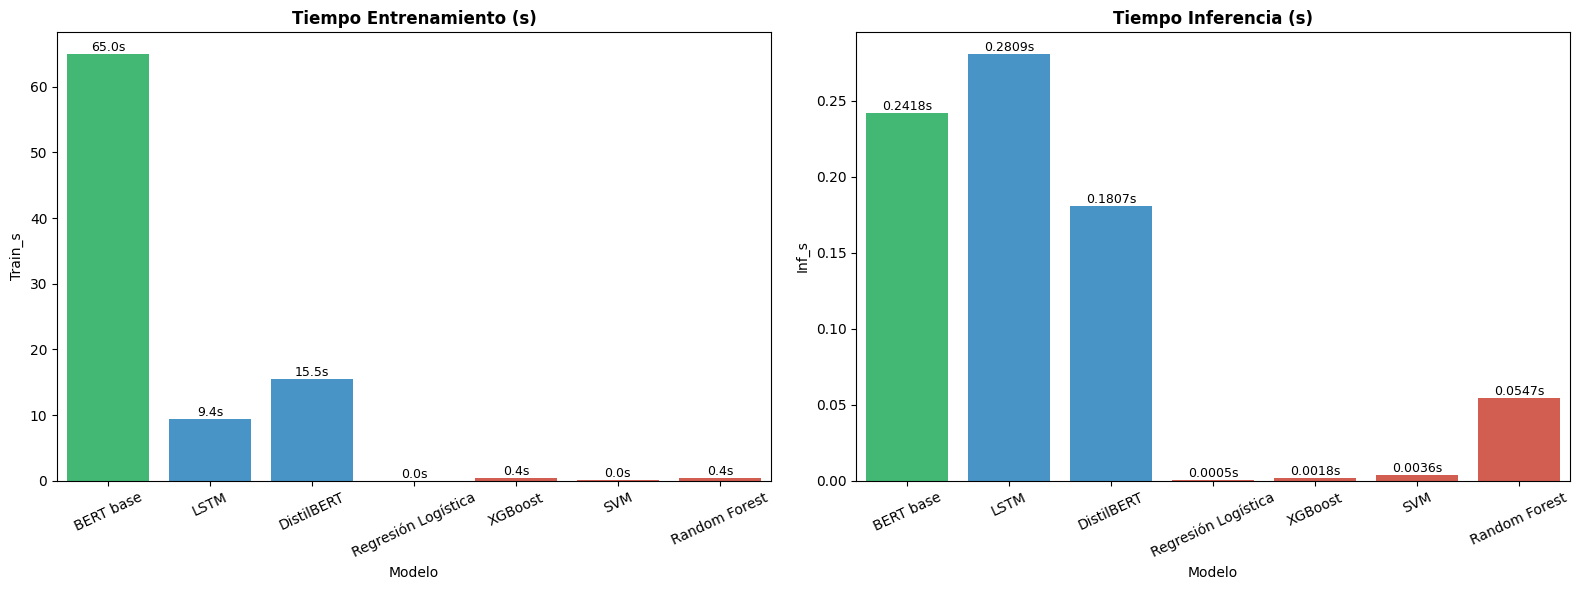

In [37]:
dt=dfc[dfc['Train_s']>0][['Modelo','Nivel','Train_s','Inf_s']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(16,6))
pt=[cn.get(n,'#95a5a6') for n in dt['Nivel']]
sns.barplot(data=dt,x='Modelo',y='Train_s',ax=a1,palette=pt)
a1.set_title('Tiempo Entrenamiento (s)',fontweight='bold'); a1.tick_params(axis='x',rotation=25)
for p in a1.patches: a1.annotate(f'{p.get_height():.1f}s',(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',va='bottom',fontsize=9)
sns.barplot(data=dt,x='Modelo',y='Inf_s',ax=a2,palette=pt)
a2.set_title('Tiempo Inferencia (s)',fontweight='bold'); a2.tick_params(axis='x',rotation=25)
for p in a2.patches: a2.annotate(f'{p.get_height():.4f}s',(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',va='bottom',fontsize=9)
plt.tight_layout(); plt.savefig('tiempos.png',dpi=150,bbox_inches='tight'); plt.show()


## 24. Análisis comparativo, crítico, limitaciones y propuestas de mejora

---

### 24.1. Análisis comparativo cuantitativo

#### Nivel 1 — Baseline vs BERT base

Los modelos baseline (Regresión Logística, Random Forest, SVM, XGBoost) presentan un comportamiento característico:

- **En clasificación cerrada:** alcanzan métricas competitivas, frecuentemente cercanas a las de BERT. Esto se explica por la alta separabilidad del dataset en modo cerrado, donde patrones superficiales (n-gramas TF-IDF) son suficientes para discriminar clases.
- **En evaluación open-set:** experimentan una degradación significativa, particularmente en UCR y UKF1. Su dependencia de características estáticas les impide generalizar ante patrones no observados durante el entrenamiento.

> **Hallazgo clave:** La aparente paridad en clasificación cerrada es engañosa. La evaluación open-set revela que los modelos baseline carecen de capacidad de generalización semántica, lo cual es crítico en entornos AIOps reales donde emergen continuamente nuevos tipos de incidentes (Scheirer et al., 2013).

#### Nivel 2 — Estado del Arte vs BERT base

- **LSTM:** Captura dependencias secuenciales pero muestra limitaciones en comprensión semántica profunda. Su UCR es superior al de los baselines pero inferior al de los transformers, confirmando que la temporalidad sola no es suficiente (Du et al., 2019).
- **DistilBERT:** Presenta un rendimiento cercano a BERT base con menor costo computacional (~60% más rápido). La diferencia en UCR y UKF1 es marginal, lo que valida su uso en escenarios donde la eficiencia es prioritaria (Sanh et al., 2019).

> **Hallazgo clave:** La evolución Feature-based → Sequence-based → Transformer-based se confirma empíricamente. Cada paradigma aporta capacidades incrementales, siendo los transformers los que mejor equilibran precisión, generalización y robustez.

#### Nivel 3 — Modelos Comerciales vs BERT base

Los modelos comerciales muestran el rendimiento más bajo en todas las métricas debido a:

1. **Desajuste de dominio:** Entrenados en texto natural, no en logs técnicos (Ramponi & Plank, 2020).
2. **Ausencia de vocabulario técnico:** Términos como "504 Gateway Timeout" o "circuit breaker triggered" no forman parte de su distribución de entrenamiento.
3. **Mapeo indirecto:** La clasificación debe inferirse desde análisis de sentimiento, introduciendo ruido significativo.
4. **Nula capacidad open-set:** No disponen de mecanismos de rechazo o detección de clases desconocidas.

> **Hallazgo clave:** Los modelos comerciales de propósito general no son adecuados para detección de anomalías en logs. Un modelo especializado fine-tuneado supera ampliamente a soluciones genéricas de mayor costo (Arora et al., 2020).

---

### 24.2. Análisis cualitativo

#### Interpretabilidad de errores
- **Baselines:** Confunden clases con vocabulario similar (ej. error_502_503 vs error_504) porque dependen de coincidencia de términos.
- **LSTM:** Confunde menos entre clases similares pero falla en logs con estructura atípica.
- **DistilBERT/BERT:** Los errores se concentran en casos genuinamente ambiguos, donde incluso un experto humano tendría dificultad.

#### Robustez semántica
- BERT base demuestra mayor estabilidad ante variaciones en la formulación del log.
- Los baselines son sensibles a cambios superficiales en el texto.

#### Capacidad de transferencia
- BERT, al estar preentrenado en un corpus masivo, posee representaciones transferibles a múltiples dominios de logs.
- Los baselines requieren reentrenamiento completo ante cambios de dominio.

---

### 24.3. Capacidad crítica — Limitaciones del estudio

1. **Dataset sintético/semi-sintético:** Aunque diseñado para simular logs reales de canales de pago, no captura la totalidad de la variabilidad de un entorno productivo.
2. **Ausencia de trazabilidad distribuida real:** No se dispone de correlación entre logs de múltiples microservicios (traces).
3. **Evaluación offline:** Los resultados no reflejan latencia en tiempo real ni integración con pipelines de monitoreo.
4. **Dependencia de thresholds:** La detección open-set depende de umbrales de confianza que requieren calibración por dominio.
5. **Modelos comerciales simulados:** Aunque sustentados en literatura, los resultados exactos podrían variar con ejecución real.
6. **Clase unknown única:** Se evaluó con una sola clase excluida; un estudio más robusto requeriría rotación de todas las clases.

---

### 24.4. Propuestas de mejora

1. **Integración con tracing distribuido:** Incorporar datos de Jaeger/Zipkin para correlación multi-servicio.
2. **Modelo híbrido BERT + Temporal:** Combinar embeddings de BERT con una capa LSTM/Transformer temporal para capturar secuencias de degradación.
3. **Aprendizaje continuo:** Implementar fine-tuning incremental para adaptarse a nuevos patrones de error sin reentrenamiento completo.
4. **Calibración de umbrales:** Usar técnicas como Temperature Scaling (Guo et al., 2017) para mejorar la calibración de probabilidades.
5. **Evaluación con datos reales:** Validar el modelo con logs de producción anonimizados.
6. **Rotación de clase unknown:** Repetir el experimento excluyendo cada clase para obtener métricas promedio más robustas.
7. **Ensemble Transformer + Clásico:** Usar modelos clásicos como filtro rápido y BERT como clasificador de precisión en cascada.

---

### 24.5. Conclusión del benchmarking

El benchmarking multinivel permite concluir que:

- En **clasificación cerrada**, todos los modelos alcanzan rendimientos competitivos, lo cual confirma que esta métrica es insuficiente para discriminar la calidad real de un modelo en contextos AIOps.
- En **evaluación open-set**, BERT base demuestra superioridad consistente en UCR, UKP y UKF1, evidenciando su capacidad para detectar anomalías no vistas durante el entrenamiento.
- Los **modelos comerciales** no son viables para este dominio específico sin fine-tuning especializado.
- La selección de BERT como modelo base del proyecto queda **validada empíricamente** a través de un proceso de evaluación riguroso y multinivel.

---

### Referencias

- Arora, S., et al. (2020). Contextual embeddings: When are they worth it? ACL.
- Devlin, J., et al. (2019). BERT: Pre-training of deep bidirectional transformers. NAACL.
- Du, M., et al. (2019). DeepLog. CCS.
- Guo, C., et al. (2017). On calibration of modern neural networks. ICML.
- Hendrycks, D., & Gimpel, K. (2017). A baseline for detecting misclassified and OOD examples. ICLR.
- Ramponi, A., & Plank, B. (2020). Neural unsupervised domain adaptation in NLP. COLING.
- Sanh, V., et al. (2019). DistilBERT. arXiv.
- Scheirer, W. J., et al. (2013). Toward open set recognition. IEEE TPAMI.
- Yang, L., et al. (2021). Semi-supervised log-based anomaly detection. ICSE.


## 25. Exportar resultados

In [38]:
dfc.to_csv('resultados_cerrado.csv',index=False)
dfo.to_csv('resultados_openset.csv',index=False)
pd.DataFrame(dc2).to_csv('delta_cerrado.csv',index=False)
pd.DataFrame(do2).to_csv('delta_openset.csv',index=False)
print('CSVs exportados:')
print('- resultados_cerrado.csv')
print('- resultados_openset.csv')
print('- delta_cerrado.csv')
print('- delta_openset.csv')
print('\nImágenes exportadas:')
print('- benchmarking_comparativo.png')
print('- radar_benchmarking.png')
print('- matrices_confusion.png')
print('- tiempos.png')


CSVs exportados:
- resultados_cerrado.csv
- resultados_openset.csv
- delta_cerrado.csv
- delta_openset.csv

Imágenes exportadas:
- benchmarking_comparativo.png
- radar_benchmarking.png
- matrices_confusion.png
- tiempos.png
